In [17]:
# Cell 1 — Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from collections import Counter
import json

In [18]:
# Cell 2 — Load dataset with ImageFolder (handles class discovery automatically)
# torchvision.datasets.ImageFolder replaces manual os.listdir() class scanning.
# It expects the structure: data_dir/<class_name>/<image_file>

data_dir = "../data/raw"

# Minimal transform just to load images as tensors for EDA
base_transform = transforms.Compose([
    transforms.ToTensor(),   # PIL Image -> [C, H, W] float tensor scaled to [0, 1]
])

dataset = datasets.ImageFolder(root=data_dir, transform=base_transform)

classes     = dataset.classes          # sorted list of class names
class_to_idx = dataset.class_to_idx    # {'AnnualCrop': 0, ...}

print(f"Classes ({len(classes)}): {classes}")
print(f"Total images : {len(dataset)}")

Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total images : 27000


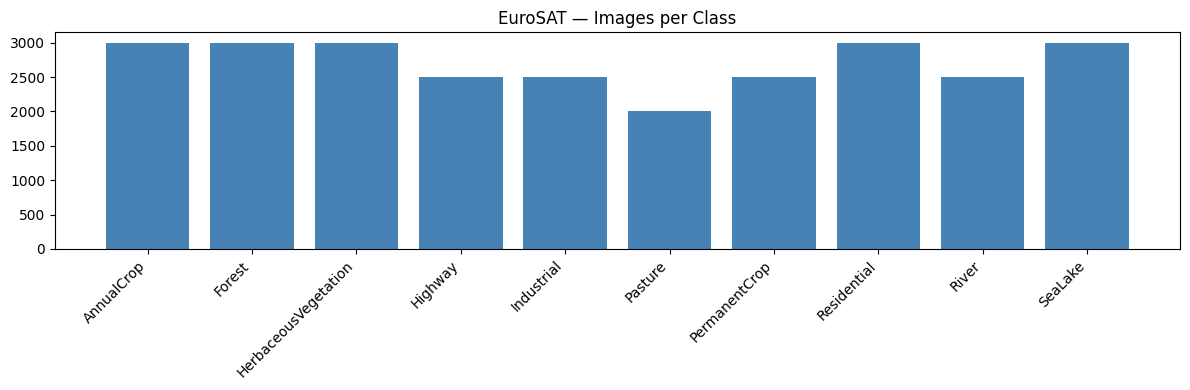

In [19]:
# Cell 3 — Class distribution using dataset.targets (no manual os.listdir needed)
# dataset.targets is a list of integer labels for every sample.

label_counts = Counter(dataset.targets)                    # {class_idx: count}
counts       = {classes[k]: v for k, v in sorted(label_counts.items())}

plt.figure(figsize=(12, 4))
plt.bar(counts.keys(), counts.values(), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("EuroSAT — Images per Class")
plt.tight_layout()
plt.savefig("../outputs/class_distribution.png")
plt.show()

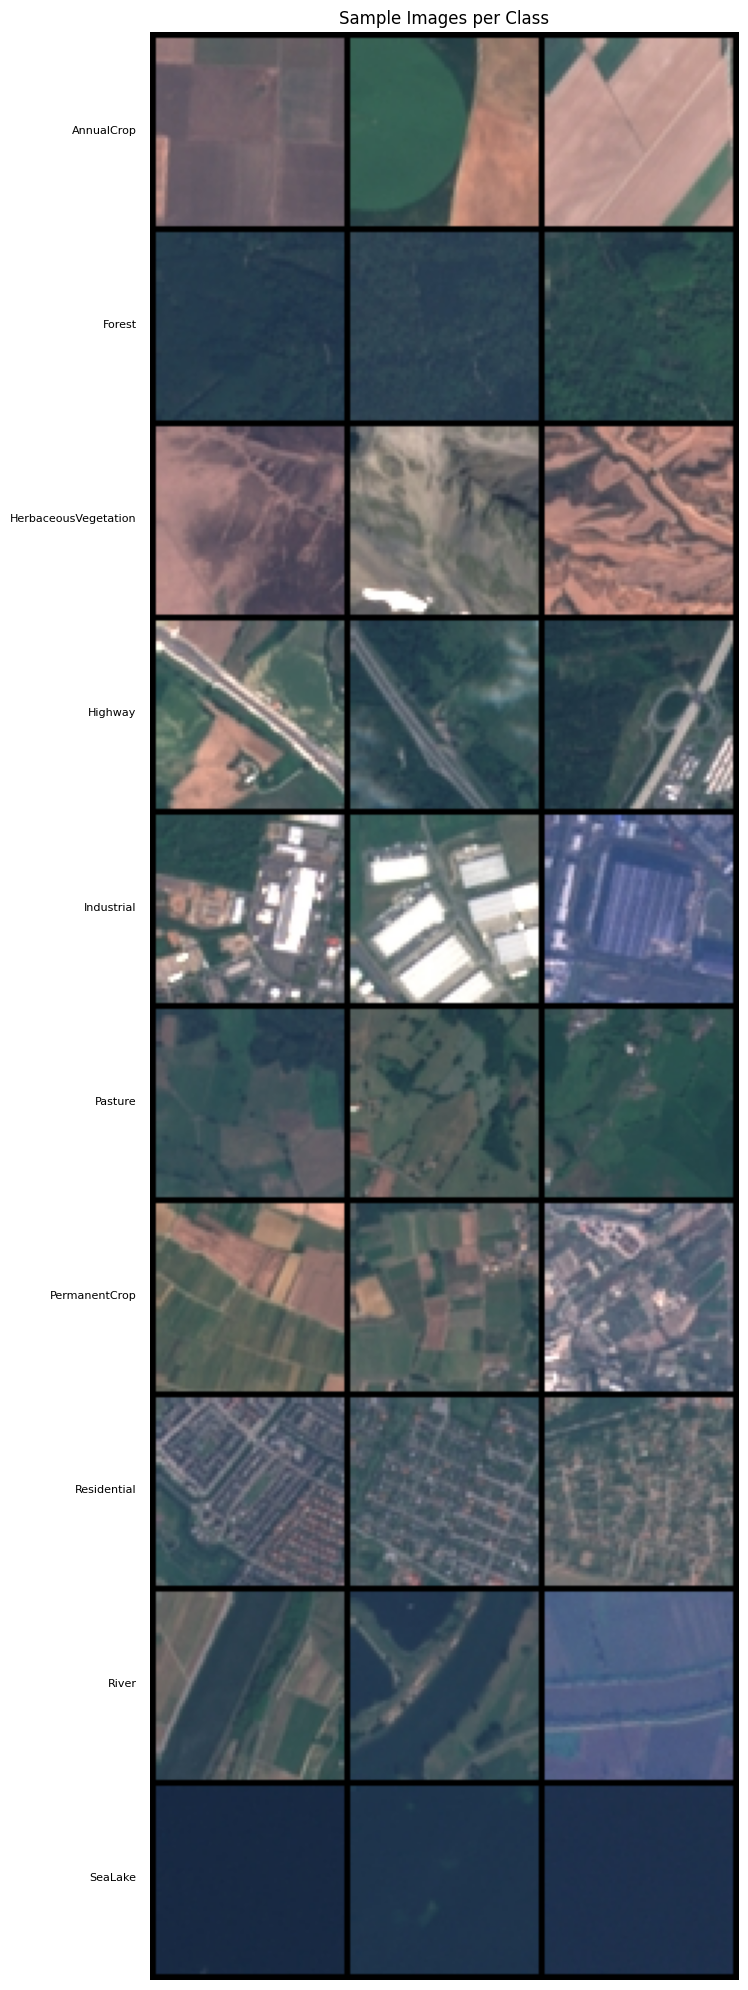

In [20]:
# Cell 4 — Sample images (3 per class) using DataLoader + make_grid
# torchvision.utils.make_grid replaces the manual PIL subplot loop.

from torchvision.utils import make_grid

samples_per_class = 3
sample_indices = []

# Collect the first N indices per class from dataset.imgs
class_seen = Counter()
for idx, (_, label) in enumerate(dataset.imgs):
    if class_seen[label] < samples_per_class:
        sample_indices.append(idx)
        class_seen[label] += 1
    if all(v >= samples_per_class for v in class_seen.values()) and len(class_seen) == len(classes):
        break
subset  = Subset(dataset, sample_indices)
loader  = DataLoader(subset, batch_size=len(sample_indices), shuffle=False)
images, labels = next(iter(loader))   # images: [N, C, H, W]

grid = make_grid(images, nrow=samples_per_class, padding=2)

# Convert [C, H, W] -> [H, W, C] for matplotlib
plt.figure(figsize=(8, len(classes) * 2))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")

# Add class-name labels on the left
img_h = images.shape[2] + 2   # height + padding
ax = plt.gca()
for i, cls in enumerate(classes):
    ax.text(-5, i * img_h + img_h // 2, cls, fontsize=8,
            va="center", ha="right", transform=ax.transData)

plt.title("Sample Images per Class")
plt.tight_layout()
plt.savefig("../outputs/sample_images.png")
plt.show()

In [21]:
# Cell 5 — Check image shapes via tensor dimensions (no numpy array conversion)
# DataLoader returns tensors with shape [B, C, H, W], so shape checking is trivial.

print("Checking image shapes...\n")

# One sample at a time; batch_size=1 to inspect individual shapes
shape_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)
shape_counter = Counter()

for imgs, _ in shape_loader:
    # imgs.shape -> (B, C, H, W); record (C, H, W) for each image
    shape = tuple(imgs.shape[1:])   # (C, H, W)
    shape_counter[shape] += imgs.shape[0]

print("Unique (C, H, W) shapes found:")
for shape, count in sorted(shape_counter.items()):
    print(f"  {shape}  →  {count} images")

if len(shape_counter) == 1:
    print("\n✓ All images have consistent shape")
else:
    print("\n⚠ Inconsistent shapes detected — check before training")

Checking image shapes...

Unique (C, H, W) shapes found:
  (3, 64, 64)  →  27000 images

✓ All images have consistent shape


In [22]:
# Cell 6 — Check for corrupted images using transforms.Lambda + try/except
# ImageFolder.verify_files() is not built in, but we can use a custom loader
# combined with PIL's verify() via a controlled pass through the dataset.

from PIL import Image, UnidentifiedImageError

print("Checking for corrupted images...\n")

corrupted = []
for path, _ in dataset.imgs:
    try:
        with Image.open(path) as img:
            img.verify()   # checks file integrity without decoding pixels
    except (UnidentifiedImageError, Exception) as e:
        corrupted.append((path, str(e)))

if not corrupted:
    print(f"✓ No corrupted images found across {len(dataset)} images")
else:
    print(f"⚠ Found {len(corrupted)} corrupted images:")
    for path, err in corrupted:
        print(f"  {path}  →  {err}")

Checking for corrupted images...

✓ No corrupted images found across 27000 images


In [23]:
# Cell 7 — Check for empty files using dataset.imgs (no manual os.walk)

import os

print("Checking for empty files...\n")

empty_files = [path for path, _ in dataset.imgs if os.path.getsize(path) == 0]

if not empty_files:
    print("✓ No empty files found")
else:
    print(f"⚠ Found {len(empty_files)} empty files:")
    for path in empty_files:
        print(f"  {path}")

Checking for empty files...

✓ No empty files found


In [26]:
# Cell 8 — Pixel mean & std per channel using DataLoader (pure PyTorch, no numpy)
# This replaces the manual stack = np.stack(pixel_vals) approach.
# Using Welford's online algorithm via accumulated sum/sum-of-squares for efficiency.
# Sample 50 per class for insight only
sample_indices = []
class_seen = Counter()
for idx, (_, label) in enumerate(dataset.imgs):
    if class_seen[label] < 50:
        sample_indices.append(idx)
        class_seen[label] += 1

subset = Subset(dataset, sample_indices)
all_imgs = torch.stack([subset[i][0] for i in range(len(subset))])  # (N, C, H, W)

print("Mean per channel (RGB):", all_imgs.mean(dim=[0, 2, 3]))
print("Std  per channel (RGB):", all_imgs.std(dim=[0, 2, 3]))

Mean per channel (RGB): tensor([0.3383, 0.3774, 0.4047])
Std  per channel (RGB): tensor([0.1966, 0.1348, 0.1153])


In [ ]:
# # save to JSON
# stats = {
#     "mean": mean.tolist(),
#     "std":  std.tolist()
# }

# os.makedirs("../outputs", exist_ok=True)
# with open("../outputs/dataset_stats.json", "w") as f:
#     json.dump(stats, f, indent=4)

# print("✓ Saved → outputs/dataset_stats.json")

✓ Saved → outputs/dataset_stats.json
